
Portfolio Construction & Daily Returns

In [447]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [448]:
prices = {
    "RELIANCE":[2800,2850,2830,2900,2880,2950],
    "INFY":[1450,1470,1460,1490,1510,1500],
    "HDFCBANK":[1600,1580,1610,1625,1615,1640],
    "TATAMOTORS":[520,535,528,540,555,548]
}

days = ["Day1","Day2","Day3","Day4","Day5","Day6"]

pricesdf = pd.DataFrame(prices,index=days)

print("Price DataFrame")
pricesdf

Price DataFrame


,RELIANCE,INFY,HDFCBANK,TATAMOTORS
Day1,2800,1450,1600,520
Day2,2850,1470,1580,535
Day3,2830,1460,1610,528
Day4,2900,1490,1625,540
Day5,2880,1510,1615,555
Day6,2950,1500,1640,548


In [449]:
returnsdf = pricesdf.pct_change()*100

print("Daily Percentage Returns (%)")
returnsdf

Daily Percentage Returns (%)


,RELIANCE,INFY,HDFCBANK,TATAMOTORS
Day1,NaN,NaN,NaN,NaN
Day2,1.785714,1.379310,-1.250000,2.884615
Day3,-0.701754,-0.680272,1.898734,-1.308411
Day4,2.473498,2.054795,0.931677,2.272727
Day5,-0.689655,1.342282,-0.615385,2.777778
Day6,2.430556,-0.662252,1.547988,-1.261261


In [450]:
investment = 1000000

weights = np.array([0.25,0.25,0.25,0.25])

allocation = investment*weights

allocation

array([250000., 250000., 250000., 250000.])

In [451]:
day1_prices = pricesdf.iloc[0]

units = allocation/day1_prices

units_df = pd.DataFrame({
    "Units Purchased":units
})

print("Units Purchased")
units_df

Units Purchased


,Units Purchased
RELIANCE,89.285714
INFY,172.413793
HDFCBANK,156.250000
TATAMOTORS,480.769231


In [452]:
portfolio_value = pricesdf.dot(units)

portfolio_value_df = pd.DataFrame({
    "Portfolio Value":portfolio_value
})

print("Daily Portfolio Value")
portfolio_value_df

Daily Portfolio Value


,Portfolio Value
Day1,1.000000e+06
Day2,1.011999e+06
Day3,1.009811e+06
Day4,1.029347e+06
Day5,1.036658e+06
Day6,1.041725e+06


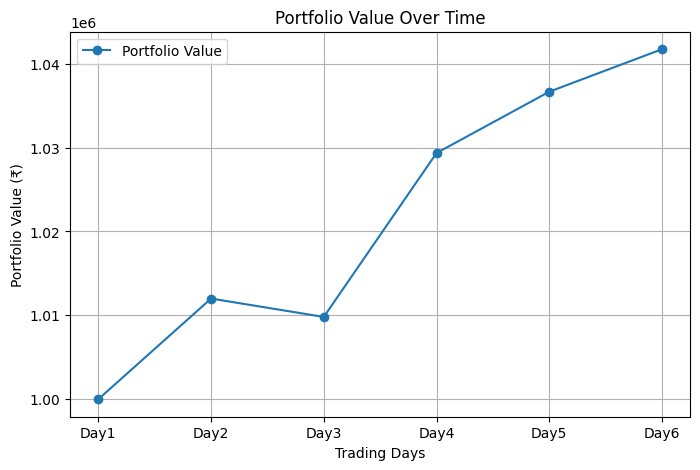

In [453]:
plt.figure(figsize=(8,5))

plt.plot(
    portfolio_value.index,
    portfolio_value.values,
    marker='o',
    label='Portfolio Value'
)

plt.title("Portfolio Value Over Time")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)

plt.show()

In [454]:
portfolio_returns = portfolio_value.pct_change().dropna()

portfolio_returns_df = pd.DataFrame({
    "Portfolio Returns":portfolio_returns
})

print("Portfolio Daily Returns")
portfolio_returns_df

Portfolio Daily Returns


,Portfolio Returns
Day2,0.011999
Day3,-0.002162
Day4,0.019346
Day5,0.007103
Day6,0.004888


In [455]:
daily_volatility = portfolio_returns.std()

print("Daily Volatility")
print(daily_volatility)

Daily Volatility
0.008034199876278432


In [456]:
annual_volatility = daily_volatility*np.sqrt(252)

print("Annualised Volatility")
print(annual_volatility)

Annualised Volatility
0.12753896913611182


In [457]:
print("Summary")

print("\nUnits Purchased")
print(units_df)

print("\nDaily Volatility")
print(daily_volatility)

print("\nAnnualised Volatility")
print(annual_volatility)

Summary

Units Purchased
            Units Purchased
RELIANCE          89.285714
INFY             172.413793
HDFCBANK         156.250000
TATAMOTORS       480.769231

Daily Volatility
0.008034199876278432

Annualised Volatility
0.12753896913611182


Problem 2 Risk Metrics — VaR, CVaR and Maximum Drawdown

In [458]:
np.random.seed(42)

simulated_returns = np.random.normal(
    loc=0.001,
    scale=0.015,
    size=50
)

returns_series = pd.Series(simulated_returns)

returns_series.head()

,0
0,0.008451
1,-0.001074
2,0.010715
3,0.023845
4,-0.002512


In [459]:
initial_value = portfolio_value.iloc[-1]

simulated_portfolio_value = initial_value * (1 + returns_series).cumprod()

simulated_portfolio_value.head()

,0
0,1.050528e+06
1,1.049400e+06
2,1.060645e+06
3,1.085936e+06
4,1.083208e+06


In [460]:
var95 = -np.percentile(simulated_returns,5)
var99 = -np.percentile(simulated_returns,1)

print("VaR 95% =",var95)
print("VaR 99% =",var99)

VaR 95% = 0.025188276651205526
VaR 99% = 0.028054086245915096


In [461]:
cvar95 = -returns_series[returns_series <= np.percentile(simulated_returns,5)].mean()

cvar99 = -returns_series[returns_series <= np.percentile(simulated_returns,1)].mean()

print("CVaR 95% =",cvar95)
print("CVaR 99% =",cvar99)

CVaR 95% = 0.027179952619501537
CVaR 99% = 0.028395051858196633


In [462]:
running_peak = simulated_portfolio_value.cummax()

drawdown = (running_peak - simulated_portfolio_value)/running_peak

drawdown.head()

,0
0,0.000000
1,0.001074
2,0.000000
3,0.000000
4,0.002512


In [463]:
max_drawdown = drawdown.max()

max_drawdown

0.18164877211654606

In [464]:
max_dd_end = drawdown.idxmax()

max_dd_start = simulated_portfolio_value[:max_dd_end+1].idxmax()

print("Maximum Drawdown =",max_drawdown)
print("Peak Index =",max_dd_start)
print("Trough Index =",max_dd_end)

Maximum Drawdown = 0.18164877211654606
Peak Index = 9
Trough Index = 49


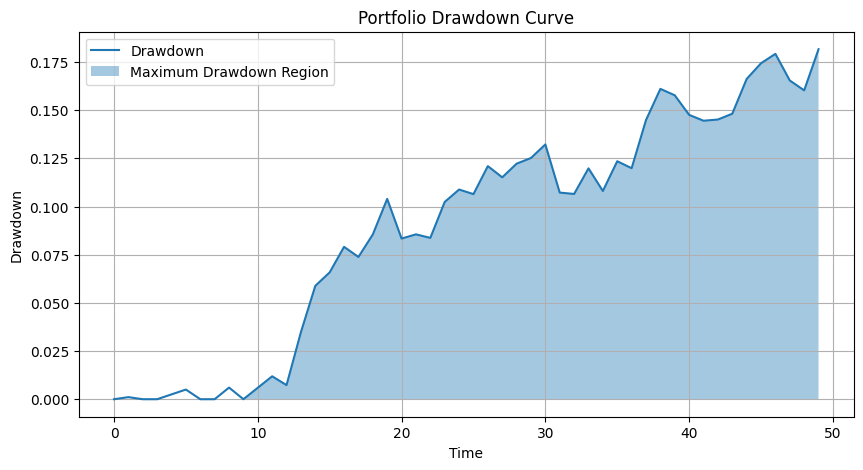

In [465]:
plt.figure(figsize=(10,5))

plt.plot(
    drawdown.index,
    drawdown.values,
    label="Drawdown"
)

plt.fill_between(
    drawdown.index,
    drawdown.values,
    where=((drawdown.index>=max_dd_start) &
           (drawdown.index<=max_dd_end)),
    alpha=0.4,
    label="Maximum Drawdown Region"
)

plt.title("Portfolio Drawdown Curve")
plt.xlabel("Time")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.show()

In [466]:
summary = pd.DataFrame({
    "Metric":[
        "VaR 95%",
        "VaR 99%",
        "CVaR 95%",
        "CVaR 99%",
        "Maximum Drawdown"
    ],
    "Value":[
        var95,
        var99,
        cvar95,
        cvar99,
        max_drawdown
    ]
})

summary

,Metric,Value
0,VaR 95%,0.025188
1,VaR 99%,0.028054
2,CVaR 95%,0.027180
3,CVaR 99%,0.028395
4,Maximum Drawdown,0.181649


 Problem 3: Risk-Adjusted Performance Metrics

In [467]:
risk_free_daily = 0.06/252

risk_free_daily

0.0002380952380952381

In [468]:
portfolio_returns = returns_series

mean_daily_return = portfolio_returns.mean()

annual_return = mean_daily_return*252

annual_volatility = portfolio_returns.std()*np.sqrt(252)

print("Annual Return =",annual_return)
print("Annual Volatility =",annual_volatility)

Annual Return = -0.6002913618682095
Annual Volatility = 0.22232298633905892


In [469]:
sharpe_ratio = (annual_return-0.06)/annual_volatility

print("Sharpe Ratio =",sharpe_ratio)

Sharpe Ratio = -2.969964432113271


In [470]:
downside_returns = portfolio_returns[
    portfolio_returns < risk_free_daily
]

In [471]:
downside_returns = portfolio_returns[
    portfolio_returns < risk_free_daily
]

In [472]:
downside_deviation = downside_returns.std() * np.sqrt(252)

print("Downside Deviation =", downside_deviation)

Downside Deviation = 0.13685707097497357


In [473]:
sortino_ratio = (annual_return-0.06)/downside_deviation

print("Sortino Ratio =",sortino_ratio)

Sortino Ratio = -4.824678455883029


In [474]:
comparison_df = pd.DataFrame({
    "Metric":["Sharpe Ratio","Sortino Ratio"],
    "Value":[sharpe_ratio,sortino_ratio]
})

comparison_df

,Metric,Value
0,Sharpe Ratio,-2.969964
1,Sortino Ratio,-4.824678


**Problem** 4: Backtesting a Simple Moving Average Strategy

In [475]:
np.random.seed(42)

days = 200

returns = np.random.normal(
    loc=0.001,
    scale=0.018,
    size=days
)

prices = [1000]

for r in returns[1:]:
    prices.append(prices[-1]*(1+r))

price_df = pd.DataFrame({
    "Price":prices
})

price_df.head()

,Price
0,1000.000000
1,998.511243
2,1011.150791
3,1039.882173
4,1036.539201


In [476]:
price_df["SMA10"] = price_df["Price"].rolling(10).mean()

price_df["SMA30"] = price_df["Price"].rolling(30).mean()

price_df.head()

,Price,SMA10,SMA30
0,1000.000000,NaN,NaN
1,998.511243,NaN,NaN
2,1011.150791,NaN,NaN
3,1039.882173,NaN,NaN
4,1036.539201,NaN,NaN


In [477]:
price_df["signal"] = 0

price_df.loc[
    price_df["SMA10"] > price_df["SMA30"],
    "signal"
] = 1

price_df.loc[
    price_df["SMA10"] < price_df["SMA30"],
    "signal"
] = -1

price_df.head(35)

,Price,SMA10,SMA30,signal
0,1000.000000,NaN,NaN,0
1,998.511243,NaN,NaN,0
2,1011.150791,NaN,NaN,0
3,1039.882173,NaN,NaN,0
4,1036.539201,NaN,NaN,0
5,1033.207281,NaN,NaN,0
6,1063.610264,NaN,NaN,0
7,1079.366400,NaN,NaN,0
8,1071.324539,NaN,NaN,0
9,1082.858505,1041.645040,NaN,0


In [478]:
price_df["crossover"] = price_df["signal"].diff()

price_df[["Price","SMA10","SMA30","signal","crossover"]].tail()

,Price,SMA10,SMA30,signal,crossover
195,1045.411800,1053.364677,1032.232545,1,0.0
196,1029.825302,1047.881255,1033.848236,1,0.0
197,1033.704708,1042.819498,1034.443673,1,0.0
198,1035.821484,1039.513742,1035.225374,1,0.0
199,1015.546868,1036.988175,1035.755344,1,0.0


In [479]:
initial_capital = 100000

In [480]:
price_df["asset_return"] = price_df["Price"].pct_change()

price_df["strategy_return"] = (
    price_df["signal"].shift(1)
    * price_df["asset_return"]
)

price_df.head()

,Price,SMA10,SMA30,signal,crossover,asset_return,strategy_return
0,1000.000000,NaN,NaN,0,NaN,NaN,NaN
1,998.511243,NaN,NaN,0,0.0,-0.001489,-0.0
2,1011.150791,NaN,NaN,0,0.0,0.012658,0.0
3,1039.882173,NaN,NaN,0,0.0,0.028415,0.0
4,1036.539201,NaN,NaN,0,0.0,-0.003215,-0.0


In [481]:
price_df["strategy_cumulative"] = (
    1 + price_df["strategy_return"].fillna(0)
).cumprod()

price_df["buyhold_cumulative"] = (
    1 + price_df["asset_return"].fillna(0)
).cumprod()

In [482]:
price_df["strategy_value"] = (
    initial_capital
    * price_df["strategy_cumulative"]
)

price_df["buyhold_value"] = (
    initial_capital
    * price_df["buyhold_cumulative"]
)

price_df.tail()

,Price,SMA10,SMA30,signal,crossover,asset_return,strategy_return,strategy_cumulative,buyhold_cumulative,strategy_value,buyhold_value
195,1045.411800,1053.364677,1032.232545,1,0.0,0.007936,0.007936,1.236376,1.045412,123637.593950,104541.180043
196,1029.825302,1047.881255,1033.848236,1,0.0,-0.014909,-0.014909,1.217942,1.029825,121794.227421,102982.530234
197,1033.704708,1042.819498,1034.443673,1,0.0,0.003767,0.003767,1.222530,1.033705,122253.032598,103370.470771
198,1035.821484,1039.513742,1035.225374,1,0.0,0.002048,0.002048,1.225034,1.035821,122503.377093,103582.148369
199,1015.546868,1036.988175,1035.755344,1,0.0,-0.019573,-0.019573,1.201056,1.015547,120105.561485,101554.686776


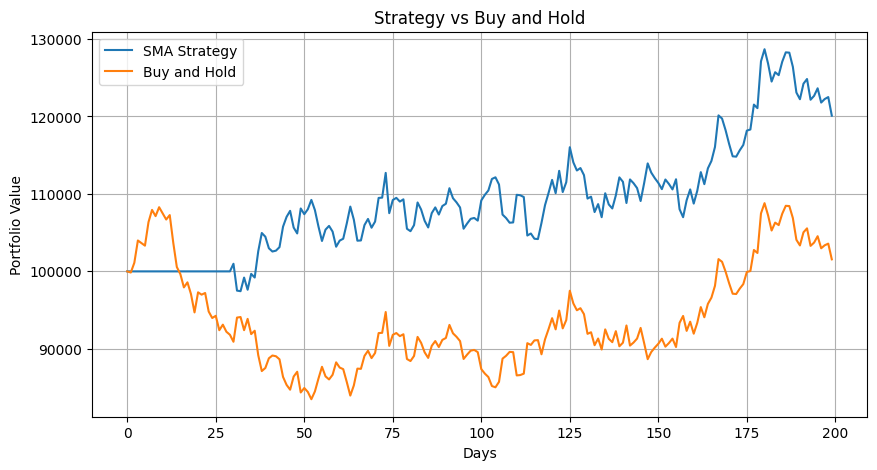

In [483]:
plt.figure(figsize=(10,5))

plt.plot(
    price_df.index,
    price_df["strategy_value"],
    label="SMA Strategy"
)

plt.plot(
    price_df.index,
    price_df["buyhold_value"],
    label="Buy and Hold"
)

plt.title("Strategy vs Buy and Hold")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

In [484]:
trade_returns = price_df["strategy_return"].dropna()

winning_trades = trade_returns[trade_returns > 0]

losing_trades = trade_returns[trade_returns < 0]

In [485]:
win_rate = len(winning_trades)/len(trade_returns)

win_rate

0.4472361809045226

In [486]:
total_profit = winning_trades.sum()

total_loss = abs(losing_trades.sum())

profit_factor = total_profit/total_loss

profit_factor

np.float64(1.2001554037593771)

In [487]:
metrics_df = pd.DataFrame({
    "Metric":[
        "Win Rate",
        "Profit Factor"
    ],
    "Value":[
        win_rate,
        profit_factor
    ]
})

metrics_df

,Metric,Value
0,Win Rate,0.447236
1,Profit Factor,1.200155



Problem 5: Feature Engineering for ML Models

In [488]:
np.random.seed(42)

days = 300

returns = np.random.normal(
    loc=0.001,
    scale=0.018,
    size=days
)

prices = [500]

for r in returns[1:]:
    prices.append(prices[-1]*(1+r))

df = pd.DataFrame({
    "Price":prices
})

df["Return1d"] = df["Price"].pct_change()
df["SMA5"] = df["Price"].rolling(5).mean()
df["SMA20"] = df["Price"].rolling(20).mean()
df["Volatility10"] = df["Return1d"].rolling(10).std()
df["Momentum5"] = df["Price"] - df["Price"].shift(5)

df = df.dropna().reset_index(drop=True)

print("Feature Data")
df.head()

Feature Data


,Price,Return1d,SMA5,SMA20,Volatility10,Momentum5
0,473.502126,-0.024421,487.936019,513.821428,0.013596,-29.328894
1,486.467408,0.027382,485.580579,513.144798,0.018731,-11.777202
2,484.976885,-0.003064,484.644080,512.430861,0.018842,-4.682492
3,486.051355,0.002216,483.270597,511.454659,0.018595,-6.867416
4,474.072392,-0.024645,481.014033,509.161225,0.017521,-11.282819


Class Balance
Target
1    151
0    129
Name: count, dtype: int64


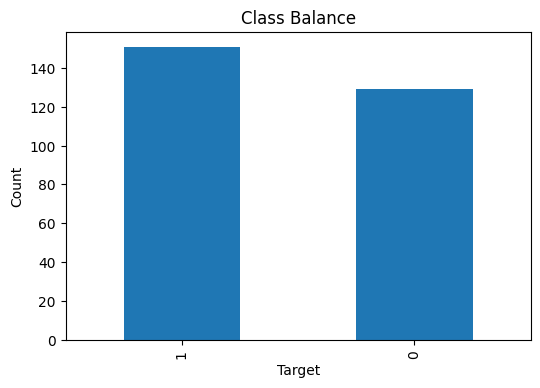

In [489]:
df["Target"] = (
    df["Return1d"].shift(-1) > 0
).astype(int)

df = df[:-1]

class_balance = df["Target"].value_counts()

print("Class Balance")
print(class_balance)

plt.figure(figsize=(6,4))

class_balance.plot(
    kind="bar",
    legend=False
)

plt.title("Class Balance")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [490]:
X = df[
    [
        "Return1d",
        "SMA5",
        "SMA20",
        "Volatility10",
        "Momentum5"
    ]
]

xmin = X.min()
xmax = X.max()

X_scaled = (X - xmin)/(xmax - xmin)

print("Scaled Features")
display(X_scaled.head())

print("\nMinimum Values")
print(X_scaled.min())

print("\nMaximum Values")
print(X_scaled.max())

Scaled Features


,Return1d,SMA5,SMA20,Volatility10,Momentum5
0,0.257818,0.316328,0.461523,0.226798,0.233485
1,0.663507,0.305072,0.457837,0.546655,0.362831
2,0.425076,0.300597,0.453948,0.553528,0.415115
3,0.466422,0.294034,0.448630,0.538124,0.399013
4,0.256064,0.283251,0.436135,0.471264,0.366474



Minimum Values
Return1d        0.0
SMA5            0.0
SMA20           0.0
Volatility10    0.0
Momentum5       0.0
dtype: float64

Maximum Values
Return1d        1.0
SMA5            1.0
SMA20           1.0
Volatility10    1.0
Momentum5       1.0
dtype: float64


 Problem 6: K-Nearest Neighbours (KNN) From Scratch

In [491]:
X = X_scaled.values
y = df["Target"].values

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 224
Testing Samples: 56


In [492]:
def euclidean_distance(x1,x2):
    return np.sqrt(np.sum((x1-x2)**2))

def knn_predict(X_train,y_train,X_test,k):

    predictions=[]

    for test_point in X_test:

        distances=[]

        for train_point in X_train:
            distances.append(
                euclidean_distance(test_point,train_point)
            )

        k_indices=np.argsort(distances)[:k]

        k_labels=y_train[k_indices]

        prediction=np.bincount(k_labels).argmax()

        predictions.append(prediction)

    return np.array(predictions)


k_values=[3,5,7,11,15]

accuracies=[]

for k in k_values:

    y_pred=knn_predict(
        X_train,
        y_train,
        X_test,
        k
    )

    accuracy=np.mean(y_pred==y_test)

    accuracies.append(accuracy)

    print(f"k = {k}  Accuracy = {accuracy:.4f}")

k = 3  Accuracy = 0.5893
k = 5  Accuracy = 0.5179
k = 7  Accuracy = 0.5536
k = 11  Accuracy = 0.4464
k = 15  Accuracy = 0.6071


Best k = 15


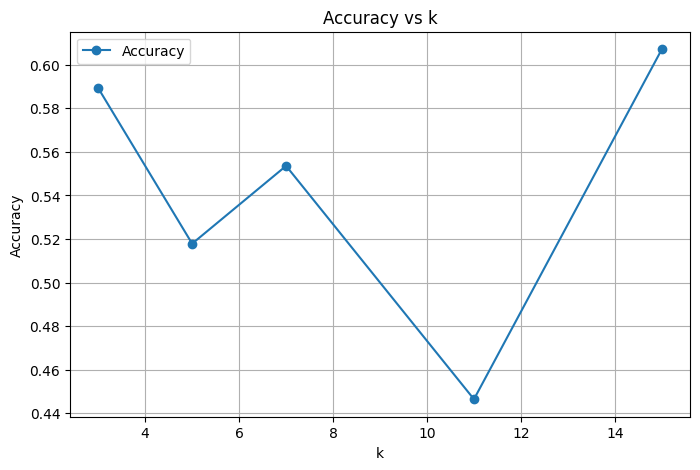

In [493]:
best_k = k_values[np.argmax(accuracies)]

print("Best k =",best_k)

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker="o",
    label="Accuracy"
)

plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [494]:
y_pred = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k
)

TP = np.sum((y_test==1) & (y_pred==1))
TN = np.sum((y_test==0) & (y_pred==0))
FP = np.sum((y_test==0) & (y_pred==1))
FN = np.sum((y_test==1) & (y_pred==0))

confusion_matrix = pd.DataFrame(
    [[TP,FP],
     [FN,TN]],
    index=["Actual Positive","Actual Negative"],
    columns=["Predicted Positive","Predicted Negative"]
)

precision = TP/(TP+FP)
recall = TP/(TP+FN)

print("Confusion Matrix")
display(confusion_matrix)

print("Precision =",precision)
print("Recall =",recall)

print("\nInterpretation:")
print("When false positive trades are costly, Precision is more important.")
print("Higher Precision means fewer incorrect buy signals and fewer costly trades.")

Confusion Matrix


,Predicted Positive,Predicted Negative
Actual Positive,21,15
Actual Negative,7,13


Precision = 0.5833333333333334
Recall = 0.75

Interpretation:
When false positive trades are costly, Precision is more important.
Higher Precision means fewer incorrect buy signals and fewer costly trades.


Problem 7: Linear Regression – Return Prediction From Scratch

In [495]:
X = X_scaled.values

y = df["Return1d"].shift(-1)

data_lr = pd.concat(
    [X_scaled, y.rename("TargetReturn")],
    axis=1
).dropna()

X = data_lr.iloc[:,:-1].values
y = data_lr["TargetReturn"].values

split = int(0.8*len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

X_train_bias = np.c_[np.ones(len(X_train)),X_train]
X_test_bias = np.c_[np.ones(len(X_test)),X_test]

beta_normal = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train

coef_df = pd.DataFrame({
    "Feature":["Bias","Return1d","SMA5","SMA20","Volatility10","Momentum5"],
    "Coefficient":beta_normal
})

print("Normal Equation Coefficients")
display(coef_df)

Normal Equation Coefficients


,Feature,Coefficient
0,Bias,0.011664
1,Return1d,-0.005901
2,SMA5,0.020512
3,SMA20,-0.019012
4,Volatility10,-0.004096
5,Momentum5,-0.014097


MSE = 0.0003550724359961823
R² = 0.02673996511853427


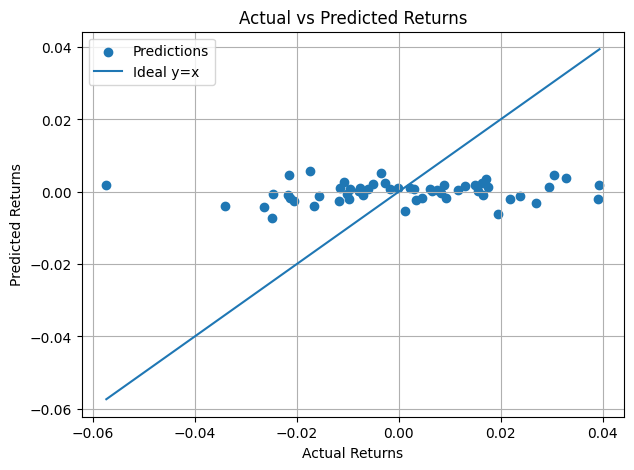

In [496]:
y_pred = X_test_bias @ beta_normal

mse = np.mean((y_test-y_pred)**2)

r2 = 1 - (
    np.sum((y_test-y_pred)**2)
    /
    np.sum((y_test-y_test.mean())**2)
)

print("MSE =",mse)
print("R² =",r2)

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    label="Predictions"
)

min_val = min(y_test.min(),y_pred.min())
max_val = max(y_test.max(),y_pred.max())

plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    label="Ideal y=x"
)

plt.title("Actual vs Predicted Returns")
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.legend()
plt.grid(True)

plt.show()

Gradient Descent Coefficients
[ 2.02312967e-03 -8.96016970e-04  1.91319591e-04 -4.92793395e-05
 -4.37476409e-04 -8.35563760e-04]


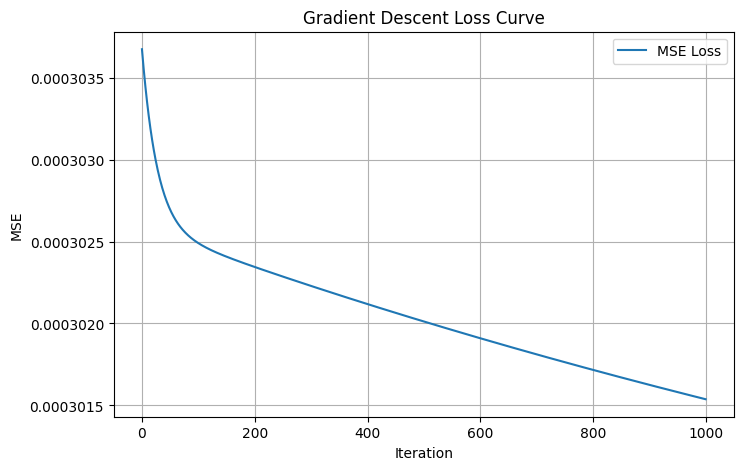


Coefficient Comparison


,Normal Equation,Gradient Descent
0,0.011664,0.002023
1,-0.005901,-0.000896
2,0.020512,0.000191
3,-0.019012,-0.000049
4,-0.004096,-0.000437
5,-0.014097,-0.000836


In [497]:
X_gd = X_train_bias.copy()

m,n = X_gd.shape

beta_gd = np.zeros(n)

eta = 0.01

iterations = 1000

losses = []

for i in range(iterations):

    predictions = X_gd @ beta_gd

    errors = predictions - y_train

    gradient = (1/m) * (X_gd.T @ errors)

    beta_gd = beta_gd - eta*gradient

    mse_loss = np.mean(errors**2)

    losses.append(mse_loss)

print("Gradient Descent Coefficients")
print(beta_gd)

plt.figure(figsize=(8,5))

plt.plot(
    losses,
    label="MSE Loss"
)

plt.title("Gradient Descent Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

comparison = pd.DataFrame({
    "Normal Equation":beta_normal,
    "Gradient Descent":beta_gd
})

print("\nCoefficient Comparison")
display(comparison)

Problem 8: Portfolio Allocation with Linear Regression

In [498]:
assets = {
    "RELIANCE":[2800,2850,2830,2900,2880,2950],
    "INFY":[1450,1470,1460,1490,1510,1500],
    "HDFCBANK":[1600,1580,1610,1625,1615,1640],
    "TATAMOTORS":[520,535,528,540,555,548]
}

predicted_returns = []

for asset,prices in assets.items():

    temp = pd.DataFrame({
        "Price":prices
    })

    temp["Return1d"] = temp["Price"].pct_change()
    temp["SMA5"] = temp["Price"].rolling(5).mean()
    temp["SMA20"] = temp["Price"].rolling(20).mean()
    temp["Volatility10"] = temp["Return1d"].rolling(10).std()
    temp["Momentum5"] = temp["Price"] - temp["Price"].shift(5)

    temp = temp.fillna(method="bfill").fillna(method="ffill")

    X_asset = temp[
        ["Return1d","SMA5","SMA20","Volatility10","Momentum5"]
    ]

    X_asset = (X_asset - xmin)/(xmax - xmin)

    latest_features = X_asset.iloc[-1].values

    latest_features = np.insert(
        latest_features,
        0,
        1
    )

    predicted_return = latest_features @ beta_normal

    predicted_returns.append(predicted_return)

predicted_returns = np.array(predicted_returns)

prediction_df = pd.DataFrame({
    "Asset":list(assets.keys()),
    "Predicted Return":predicted_returns
})

display(prediction_df)

/tmp/ipykernel_7539/907588726.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_7539/907588726.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_7539/907588726.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method="bfill").fillna(method="ffill")
/tmp/ipykernel_7539/907588726.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method="bfill").fillna(method="ffill")


,Asset,Predicted Return
0,RELIANCE,NaN
1,INFY,NaN
2,HDFCBANK,NaN
3,TATAMOTORS,NaN


In [499]:
positive_returns = np.maximum(
    predicted_returns,
    0
)

if positive_returns.sum() == 0:
    weights = np.ones(len(predicted_returns))/len(predicted_returns)
else:
    weights = positive_returns/positive_returns.sum()

weights_df = pd.DataFrame({
    "Asset":list(assets.keys()),
    "Weight":weights
})

display(weights_df)

print("Sum of Weights =",weights.sum())

,Asset,Weight
0,RELIANCE,NaN
1,INFY,NaN
2,HDFCBANK,NaN
3,TATAMOTORS,NaN


Sum of Weights = nan


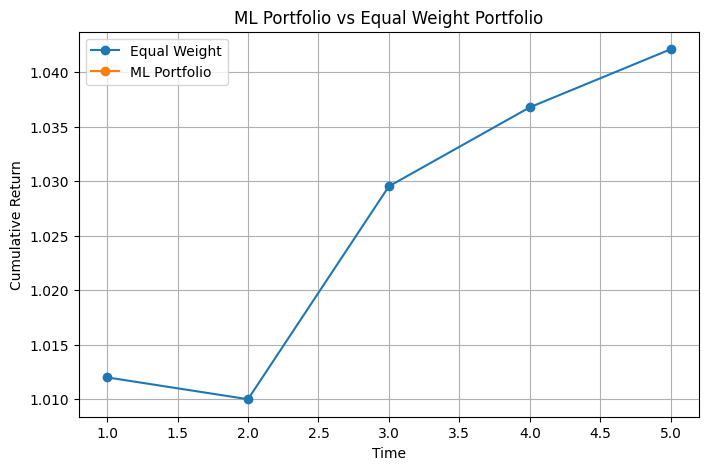

Final Equal Weight Return = 0.04209284779006395
Final ML Return = nan


In [500]:
prices_df = pd.DataFrame(assets)

returns_df = prices_df.pct_change().dropna()

equal_weights = np.array([0.25,0.25,0.25,0.25])

equal_portfolio = (
    returns_df @ equal_weights
)

ml_portfolio = (
    returns_df @ weights
)

equal_cumulative = (
    1 + equal_portfolio
).cumprod()

ml_cumulative = (
    1 + ml_portfolio
).cumprod()

plt.figure(figsize=(8,5))

plt.plot(
    equal_cumulative.index,
    equal_cumulative.values,
    marker="o",
    label="Equal Weight"
)

plt.plot(
    ml_cumulative.index,
    ml_cumulative.values,
    marker="o",
    label="ML Portfolio"
)

plt.title("ML Portfolio vs Equal Weight Portfolio")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)

plt.show()

print("Final Equal Weight Return =",equal_cumulative.iloc[-1]-1)
print("Final ML Return =",ml_cumulative.iloc[-1]-1)

 Problem 9: Model Comparison and Hyperparameter Tuning

In [502]:


X_knn = X_scaled.values
y_knn = df["Target"].values

def k_fold_knn(X,y,k_value,n_folds=5):

    fold_size = len(X)//n_folds

    accuracies = []

    for fold in range(n_folds):

        start = fold*fold_size
        end = start+fold_size

        X_val = X[start:end]
        y_val = y[start:end]

        X_train = np.concatenate(
            [X[:start],X[end:]],
            axis=0
        )

        y_train = np.concatenate(
            [y[:start],y[end:]],
            axis=0
        )

        y_pred = knn_predict(
            X_train,
            y_train,
            X_val,
            k_value
        )

        accuracy = np.mean(y_pred==y_val)

        accuracies.append(accuracy)

    return np.mean(accuracies), np.std(accuracies)


k_values = [3,7,11]

cv_results = []

for k in k_values:

    mean_acc,std_acc = k_fold_knn(
        X_knn,
        y_knn,
        k
    )

    cv_results.append(
        [k,mean_acc,std_acc]
    )

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "k",
        "Mean Accuracy",
        "Std Accuracy"
    ]
)

print("Cross Validation Results")
display(cv_df)


best_row = cv_df.iloc[
    cv_df["Mean Accuracy"].idxmax()
]

best_knn_k = int(best_row["k"])
best_knn_accuracy = best_row["Mean Accuracy"]


comparison_df = pd.DataFrame({
    "Model":[
        "KNN Classifier",
        "Linear Regression"
    ],
    "Accuracy/R²":[
        best_knn_accuracy,
        r2
    ],
    "MSE/N.A.":[
        "N.A.",
        mse
    ],
    "Best Param":[
        f"k={best_knn_k}",
        "Normal Equation"
    ]
})

print("\nModel Comparison")
display(comparison_df)

print("\nDiscussion")
print("1. The model with stronger validation performance should be preferred.")
print("2. Overfitting can make historical performance look unrealistically good.")
print("3. Look-ahead bias can leak future information into training data.")
print("4. Market conditions may change and reduce future performance.")

Cross Validation Results


,k,Mean Accuracy,Std Accuracy
0,3,0.482143,0.104124
1,7,0.500000,0.065854
2,11,0.514286,0.087773



Model Comparison


,Model,Accuracy/R²,MSE/N.A.,Best Param
0,KNN Classifier,0.514286,N.A.,k=11
1,Linear Regression,0.026740,0.000355,Normal Equation



Discussion
1. The model with stronger validation performance should be preferred.
2. Overfitting can make historical performance look unrealistically good.
3. Look-ahead bias can leak future information into training data.
4. Market conditions may change and reduce future performance.


Problem 10: Theory, Design and Reflection

(a) Diversification

The portfolio variance formula contains covariance terms involving the correlation coefficient ρij between assets. When assets have low or negative correlation, the covariance terms become smaller or negative, reducing total portfolio variance. As a result, fluctuations in one asset can be offset by movements in another asset. Therefore, combining imperfectly correlated assets reduces overall portfolio risk without necessarily reducing expected returns. This is the mathematical basis of diversification.

(b) Technical vs Fundamental Analysis in ML

One useful fundamental feature is the Price-to-Earnings (P/E) ratio. The P/E ratio measures how much investors are willing to pay for each unit of company earnings. This data can be obtained from company financial statements or financial data providers such as Yahoo Finance. The feature can be added as an additional column in the dataset and scaled together with other features before applying KNN. Combining technical and fundamental features may improve prediction performance.

(c) Curse of Dimensionality

As the number of features increases, distances between data points become increasingly similar. This makes it difficult to identify meaningful nearest neighbours because all points appear nearly equidistant. Consequently, KNN may experience reduced predictive accuracy and increased computational cost. One way to mitigate this problem is dimensionality reduction using techniques such as Principal Component Analysis (PCA), which preserves important information while reducing the number of features.

(d) Overfitting in Backtesting

A large gap between backtest and live performance may occur due to several reasons. First, look-ahead bias occurs when future information accidentally enters the training process; walk-forward validation can help detect it. Second, survivorship bias arises when failed assets are excluded from historical datasets; using survivorship-bias-free databases helps identify this issue. Third, data snooping occurs when many strategies are tested and only the best one is reported; out-of-sample testing can help detect and reduce this problem.

(e) Linear Regression Assumptions

One common violation is autocorrelation, where return observations are correlated across time rather than being independent. This can lead to biased estimates of statistical significance and unreliable predictions. Another violation is heteroscedasticity, where the variance of errors changes over time, often increasing during volatile market periods. This causes the model to underestimate or overestimate uncertainty and may reduce forecasting accuracy during changing market conditions.